Q1

In [1]:
total = 52
red = 26
hearts = 13
face_cards = 12
diamond_faces = 3
spade_faces = 3
queens = 4

p_red = red / total
p_heart_given_red = hearts / red
p_diamond_given_face = diamond_faces / face_cards
p_spade_or_queen_given_face = (spade_faces + queens - 1) / face_cards

print(f"P(Red) = {p_red}")
print(f"P(Heart | Red) = {p_heart_given_red}")
print(f"P(Diamond | Face) = {round(p_diamond_given_face, 4)}")
print(f"P(Spade or Queen | Face) = {round(p_spade_or_queen_given_face, 4)}")

P(Red) = 0.5
P(Heart | Red) = 0.5
P(Diamond | Face) = 0.25
P(Spade or Queen | Face) = 0.5


Q2

/tmp/ipykernel_14310/324435349.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


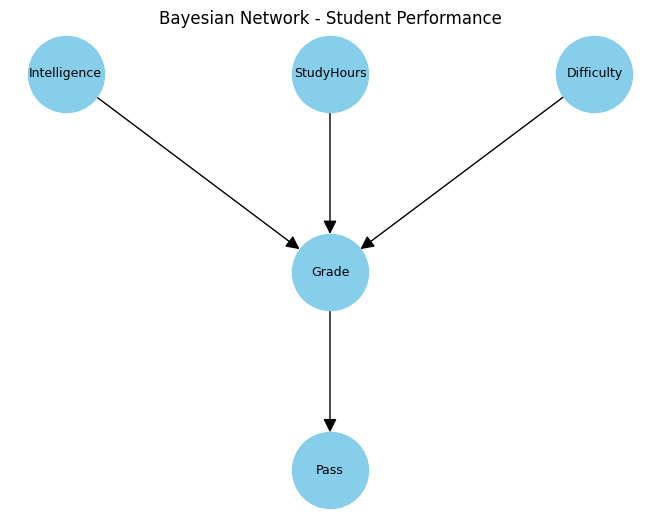

Model valid: True

P(Pass | StudyHours=Sufficient, Difficulty=Hard)
+--------+----------+
| P      |   phi(P) |
+========+==========+
| P(Yes) |   0.7715 |
+--------+----------+
| P(No)  |   0.2285 |
+--------+----------+

P(Intelligence | Pass=Yes)
+---------+----------+
| I       |   phi(I) |
+=========+==========+
| I(High) |   0.7407 |
+---------+----------+
| I(Low)  |   0.2593 |
+---------+----------+


In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

edges = [('I', 'G'), ('S', 'G'), ('D', 'G'), ('G', 'P')]

G = nx.DiGraph()
G.add_edges_from(edges)

pos = {'I': (0, 1), 'S': (1, 1), 'D': (2, 1), 'G': (1, 0), 'P': (1, -1)}
labels = {'I': 'Intelligence', 'S': 'StudyHours', 'D': 'Difficulty', 'G': 'Grade', 'P': 'Pass'}

nx.draw(G, pos, labels=labels, with_labels=True,
  node_color='skyblue', node_size=3000, font_size=9,
  arrows=True, arrowsize=20)
plt.title("Bayesian Network - Student Performance")
plt.tight_layout()
plt.show()

model = DiscreteBayesianNetwork(edges)

cpd_i = TabularCPD('I', 2, [[0.7], [0.3]],
  state_names={'I': ['High', 'Low']})

cpd_s = TabularCPD('S', 2, [[0.6], [0.4]],
  state_names={'S': ['Sufficient', 'Insufficient']})

cpd_d = TabularCPD('D', 2, [[0.4], [0.6]],
  state_names={'D': ['Hard', 'Easy']})

cpd_g = TabularCPD('G', 3,
  [[0.50, 0.70, 0.20, 0.40, 0.10, 0.30, 0.05, 0.10],
   [0.35, 0.20, 0.40, 0.40, 0.30, 0.40, 0.20, 0.30],
   [0.15, 0.10, 0.40, 0.20, 0.60, 0.30, 0.75, 0.60]],
  evidence=['I', 'S', 'D'],
  evidence_card=[2, 2, 2],
  state_names={
    'G': ['A', 'B', 'C'],
    'I': ['High', 'Low'],
    'S': ['Sufficient', 'Insufficient'],
    'D': ['Hard', 'Easy']
  })

cpd_p = TabularCPD('P', 2,
  [[0.95, 0.80, 0.50],
   [0.05, 0.20, 0.50]],
  evidence=['G'],
  evidence_card=[3],
  state_names={'P': ['Yes', 'No'], 'G': ['A', 'B', 'C']})

model.add_cpds(cpd_i, cpd_s, cpd_d, cpd_g, cpd_p)
print("Model valid:", model.check_model())

infer = VariableElimination(model)

r1 = infer.query(['P'], evidence={'S': 'Sufficient', 'D': 'Hard'})
print("\nP(Pass | StudyHours=Sufficient, Difficulty=Hard)")
print(r1)

r2 = infer.query(['I'], evidence={'P': 'Yes'})
print("\nP(Intelligence | Pass=Yes)")
print(r2)

Q3

In [7]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

model = DiscreteBayesianNetwork([
  ('Disease', 'Fever'),
  ('Disease', 'Cough'),
  ('Disease', 'Fatigue'),
  ('Disease', 'Chills')
])

cpd_disease = TabularCPD('Disease', 2, [[0.3], [0.7]],
  state_names={'Disease': ['Flu', 'Cold']})

cpd_fever = TabularCPD('Fever', 2,
  [[0.9, 0.5], [0.1, 0.5]],
  evidence=['Disease'], evidence_card=[2],
  state_names={'Fever': ['Yes', 'No'], 'Disease': ['Flu', 'Cold']})

cpd_cough = TabularCPD('Cough', 2,
  [[0.8, 0.6], [0.2, 0.4]],
  evidence=['Disease'], evidence_card=[2],
  state_names={'Cough': ['Yes', 'No'], 'Disease': ['Flu', 'Cold']})

cpd_fatigue = TabularCPD('Fatigue', 2,
  [[0.7, 0.3], [0.3, 0.7]],
  evidence=['Disease'], evidence_card=[2],
  state_names={'Fatigue': ['Yes', 'No'], 'Disease': ['Flu', 'Cold']})

cpd_chills = TabularCPD('Chills', 2,
  [[0.6, 0.4], [0.4, 0.6]],
  evidence=['Disease'], evidence_card=[2],
  state_names={'Chills': ['Yes', 'No'], 'Disease': ['Flu', 'Cold']})

model.add_cpds(cpd_disease, cpd_fever, cpd_cough, cpd_fatigue, cpd_chills)

infer = VariableElimination(model)

r1 = infer.query(['Disease'], evidence={'Fever': 'Yes', 'Cough': 'Yes'})
print("P(Disease | Fever=Yes, Cough=Yes)")
print(r1)

r2 = infer.query(['Disease'], evidence={'Fever': 'Yes', 'Cough': 'Yes', 'Chills': 'Yes'})
print("\nP(Disease | Fever=Yes, Cough=Yes, Chills=Yes)")
print(r2)

r3 = infer.query(['Fatigue'], evidence={'Disease': 'Flu'})
print("\nP(Fatigue | Disease=Flu)")
print(r3)

P(Disease | Fever=Yes, Cough=Yes)
+---------------+----------------+
| Disease       |   phi(Disease) |
+===============+================+
| Disease(Flu)  |         0.5070 |
+---------------+----------------+
| Disease(Cold) |         0.4930 |
+---------------+----------------+

P(Disease | Fever=Yes, Cough=Yes, Chills=Yes)
+---------------+----------------+
| Disease       |   phi(Disease) |
+===============+================+
| Disease(Flu)  |         0.6067 |
+---------------+----------------+
| Disease(Cold) |         0.3933 |
+---------------+----------------+

P(Fatigue | Disease=Flu)
+--------------+----------------+
| Fatigue      |   phi(Fatigue) |
+==============+================+
| Fatigue(Yes) |         0.7000 |
+--------------+----------------+
| Fatigue(No)  |         0.3000 |
+--------------+----------------+


Q4

In [9]:
import numpy as np

states = ['Sunny', 'Cloudy', 'Rainy']
transition = np.array([
  [0.6, 0.3, 0.1],
  [0.3, 0.4, 0.3],
  [0.2, 0.3, 0.5]
])

np.random.seed(42)
current = 0
sequence = [states[current]]

for _ in range(9):
  current = np.random.choice(3, p=transition[current])
  sequence.append(states[current])

print("10-day forecast:", sequence)
print("Rainy days:", sequence.count('Rainy'))

trials = 100000
rainy_3_plus = 0

for _ in range(trials):
  current = 0
  rainy = 0
  for _ in range(10):
    current = np.random.choice(3, p=transition[current])
    if states[current] == 'Rainy':
      rainy += 1
  if rainy >= 3:
    rainy_3_plus += 1

print(f"P(at least 3 rainy days) ≈ {rainy_3_plus / trials:.4f}")

10-day forecast: ['Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Cloudy', 'Cloudy']
Rainy days: 3
P(at least 3 rainy days) ≈ 0.4492
